<a href="https://colab.research.google.com/github/zhangminxi-bit/ECON3916/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install category_encoders

import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

import missingno as msno

import category_encoders as ce

import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


# Phase 1


## Step 1.1

The foundamental omitted confounder is misunderstanding the correlation between high deductible insurance plan and inpatient admission rate. Instead of one causing another, the patient with low socialeconomic status (poverty, wealth, etc.) can be the factor which determines both factors. Therefore, the causal Directed Acyclic Graph (DAG) for this task is: 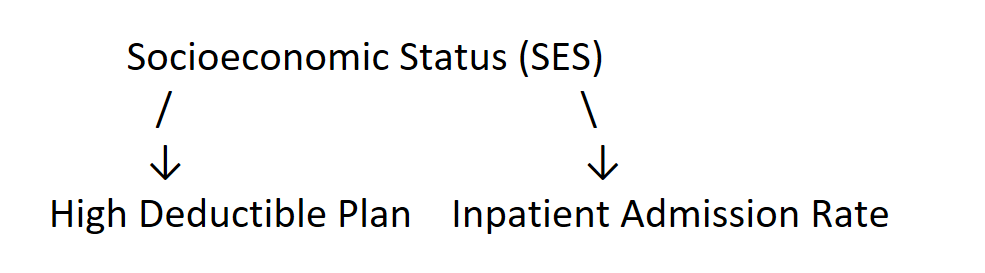

Since the patient's socialeconomic status is correlated with both independent variable and the error term, ignoring this factor can lead to Omitted Variable Bias (OVB).

## Step 1.2

In [3]:
df = pd.read_csv('OmniCare_Clinical_Vitals.csv')
df2 = pd.read_csv('OmniCare_Telemetry_Data.csv')
print(df.head())
print(df2.head())

   Patient_ID  Height_cm  Weight_kg    BMI  Systolic_BP  Diastolic_BP
0        1000      177.5       66.3  21.06        110.0          75.0
1        1001      167.9       57.5  20.39        115.0          79.0
2        1002      179.7       57.4  17.77        111.0          77.0
3        1003      192.8       80.9  21.76        122.0          88.0
4        1004      166.5       65.7  23.70        138.0          89.0
   Patient_ID  High_Deductible_Insurance_Plan  Inpatient_Admission_Rate  \
0        1000                               1                     0.341   
1        1001                               0                     0.213   
2        1002                               0                     0.166   
3        1003                               1                     0.143   
4        1004                               0                     0.219   

   Continuous_Heart_Rate Primary_Diagnosis_Code  Clinic_Capacity_Percentage  \
0                   76.9                J86.381   

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select continuous variables
features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]
X = df[features].dropna()

# Add constant (required for VIF calculation)
X_const = X.copy()
X_const["Intercept"] = 1

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print(vif_data)

        Feature          VIF
0     Weight_kg    57.428058
1     Height_cm    28.419446
2           BMI    16.981232
3   Systolic_BP     4.219406
4  Diastolic_BP     4.219820
5     Intercept  3369.565806


Since BMI is calculated using the patient's weight and height, severe multicollinearity is witnessed between BMI, height, and weight. Therefore, weight and height will be dropped as they have a weak correlation with each other with only BMI kept.

In [5]:
features_final = ["BMI", "Systolic_BP", "Diastolic_BP"]
X_final = df[features_final].dropna()

X_final_const = X_final.copy()
X_final_const["Intercept"] = 1

vif_final = pd.DataFrame()
vif_final["Feature"] = X_final_const.columns
vif_final["VIF"] = [
    variance_inflation_factor(X_final_const.values, i)
    for i in range(X_final_const.shape[1])
]

print(vif_final)

        Feature         VIF
0           BMI    1.000178
1   Systolic_BP    4.219207
2  Diastolic_BP    4.219571
3     Intercept  116.601971


# Phase 2

## Step 2.1


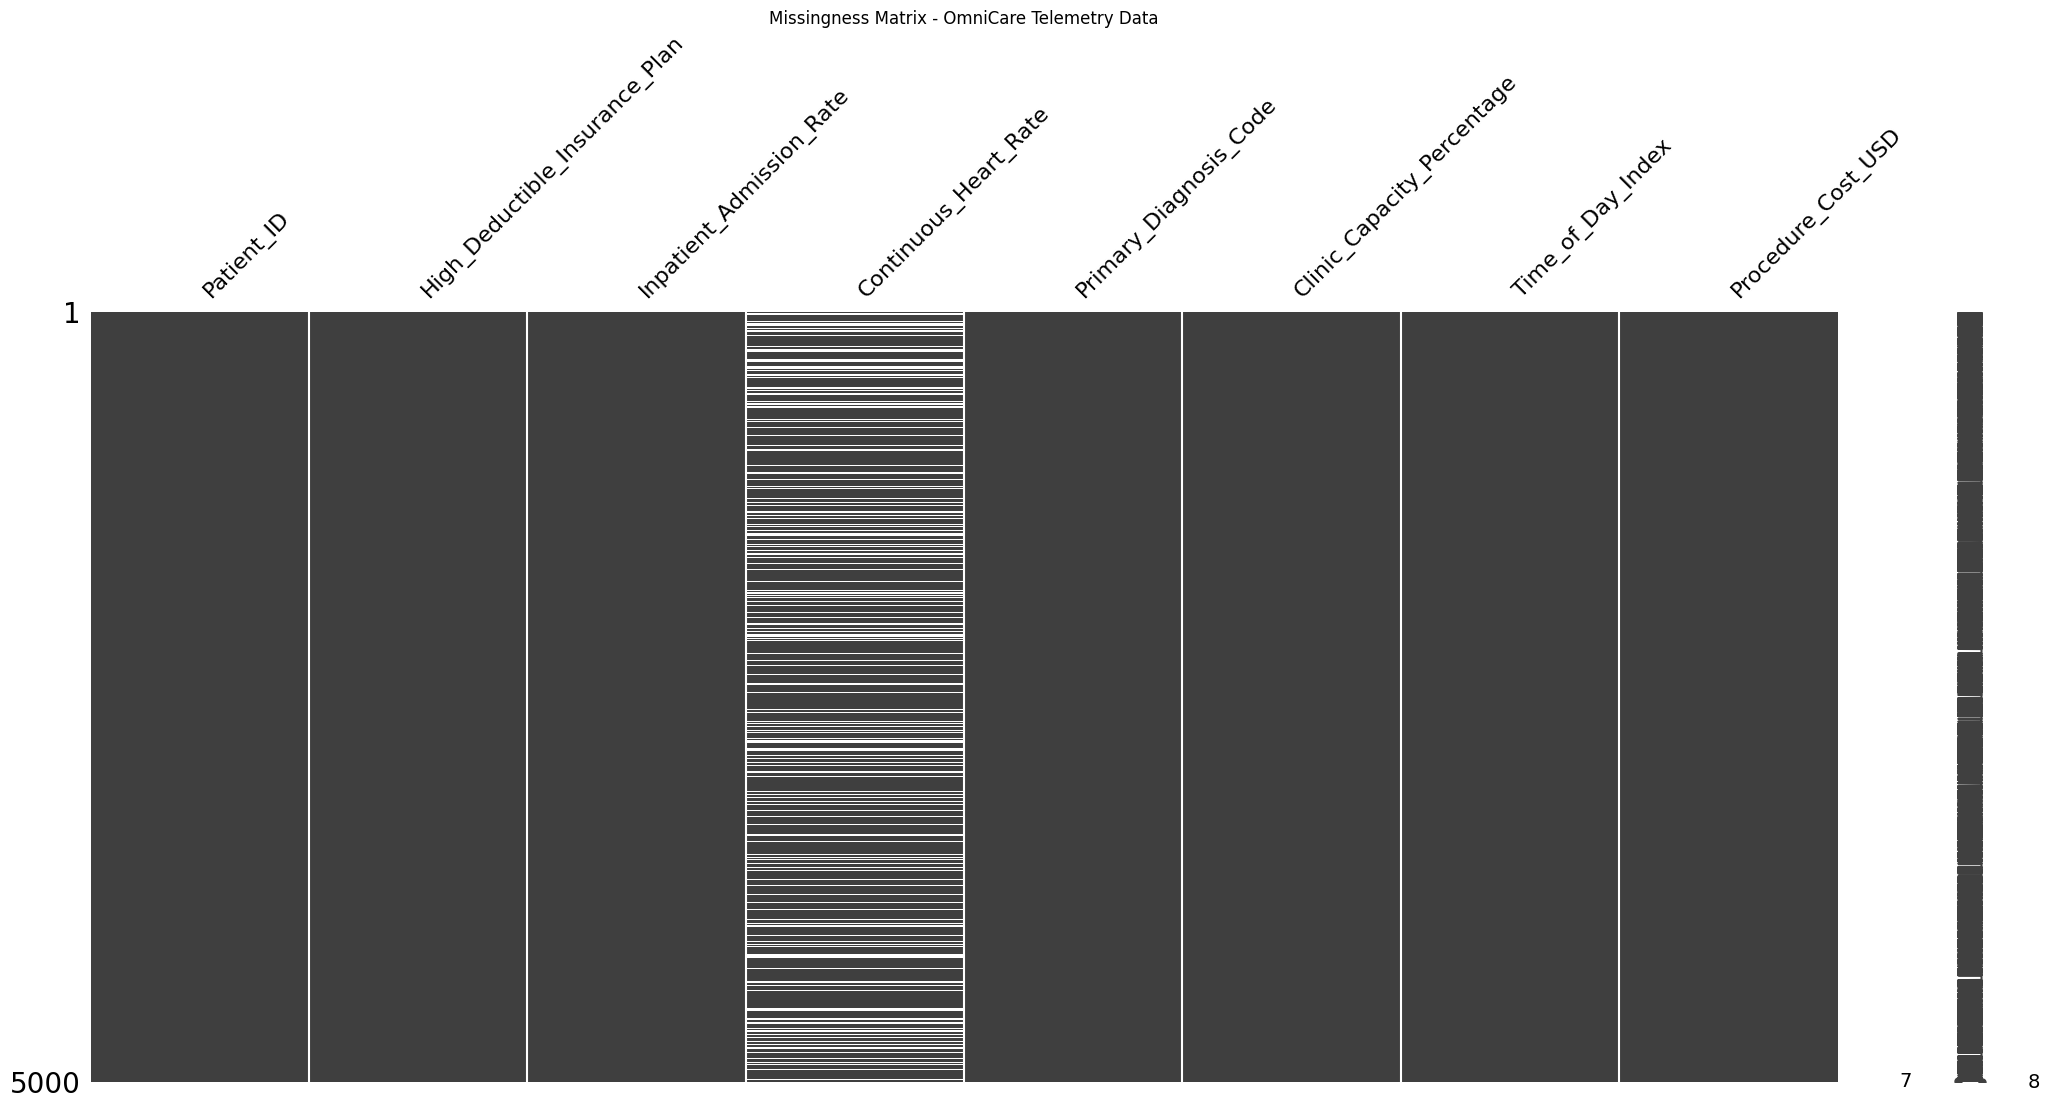

In [6]:
msno.matrix(df2)
plt.title("Missingness Matrix - OmniCare Telemetry Data")
plt.show()

The missingness in Continuous_Heart_Rate is non-random and systematic. According to Rubin's taxonomy, the missingness is MNAR (Missing Not At Random). The main reason is that the socialeconomic status is unobserved, and the bias, as well as variance distortion, due to this unobserved factor leads to the missingness. Thus, the naive mean imputation method would influence both the statistical validity and the causal interpretability of the dataset.

## Step 2.2

In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient_ID                      5000 non-null   int64  
 1   High_Deductible_Insurance_Plan  5000 non-null   int64  
 2   Inpatient_Admission_Rate        5000 non-null   float64
 3   Continuous_Heart_Rate           3786 non-null   float64
 4   Primary_Diagnosis_Code          5000 non-null   object 
 5   Clinic_Capacity_Percentage      5000 non-null   float64
 6   Time_of_Day_Index               5000 non-null   float64
 7   Procedure_Cost_USD              5000 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 312.6+ KB


The formula to the OLS estimator is:
  #  β​=(XTX)^(−1)XTy, where XT refers to the transpose of X
When X shifts from a categorical variable to 850 binary variables using `pd.get_dummies()`, the sum of each row becomes 1. Since XTX is singular, (XTX)^(-1) becomes undefined. Therefore, the OLS estimator is undefined, and this destroys the entire OLS estimation.

# Step 2.3

In [8]:
# Define variables
X = df2[["Primary_Diagnosis_Code"]]
y = df2["Procedure_Cost_USD"]

# Initialize Target Encoder
encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])

# Fit and transform
X_encoded = encoder.fit_transform(X, y)

# Combine back if needed
df_encoded = df2.copy()
df_encoded["Primary_Diagnosis_Encoded"] = X_encoded["Primary_Diagnosis_Code"]

# Print first five rows of encoded column
print(df_encoded[["Primary_Diagnosis_Code", "Primary_Diagnosis_Encoded"]].head())

  Primary_Diagnosis_Code  Primary_Diagnosis_Encoded
0                J86.381                1707.697108
1                M29.789                1792.303198
2                E49.618                1730.334968
3                E66.244                1725.060944
4                J45.553                1801.821085


# Phase 3

## Step 3.1

In [9]:
# -----------------------------
# Step 1: Merge DataFrames
# -----------------------------
merged_df = pd.merge(df, df2, on="Patient_ID", how="inner")

# -----------------------------
# Step 2: Target Encoding
# -----------------------------
encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])
merged_df["Primary_Diagnosis_Encoded"] = encoder.fit_transform(
    merged_df[["Primary_Diagnosis_Code"]],
    merged_df["Procedure_Cost_USD"]
)

# -----------------------------
# Step 3: Feature Selection (sanitized)
# Drop Weight & Height, keep BMI to avoid multicollinearity
# -----------------------------
final_df = merged_df[[
    "Procedure_Cost_USD",
    "Primary_Diagnosis_Encoded",
    "Clinic_Capacity_Percentage",
    "Time_of_Day_Index",
    "BMI",
    "Systolic_BP",
    "Diastolic_BP"
]].dropna()

# -----------------------------
# Step 4: OLS via Patsy Formula
# -----------------------------
formula = """
Procedure_Cost_USD ~
Primary_Diagnosis_Encoded +
Clinic_Capacity_Percentage +
Time_of_Day_Index +
BMI +
Systolic_BP +
Diastolic_BP
"""

model = smf.ols(formula=formula, data=final_df).fit()

# -----------------------------
# Step 5: Output Summary
# -----------------------------
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     267.0
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          3.60e-297
Time:                        02:32:38   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4993   BIC:                         7.238e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

## Step 3.2

In [10]:
from statsmodels.tools.eval_measures import rmse

# Predictions from your fitted model
y_true = final_df["Procedure_Cost_USD"]
y_pred = model.predict(final_df)

# RMSE
model_rmse = rmse(y_true, y_pred)
print(f"RMSE: ${model_rmse:.2f}")

RMSE: $334.79


If the RMSE is 450, it means that the average pricing error is 450/1200=37.5%.

The operational risk is the inconsistency of pricing, which in this case, can vary from 750 to 1650. This might cause catastrophic loss of trust from the customers.

The financial risk is the unstable revenue that flucuates with rise (when underpriced) and fall (when overpriced) of demand. This might make any forecast to the hospital unreliable.

Furthermore, the issue of adverse selection may be witnessed if the flexible price is implemented. This indicates that only patients with complex and high-risk issues will seek for the service, since their cases are likely to be underpriced. Whereas simple patients will move to other hospitals instead, as they are likely to be overpriced.

## Step 3.3

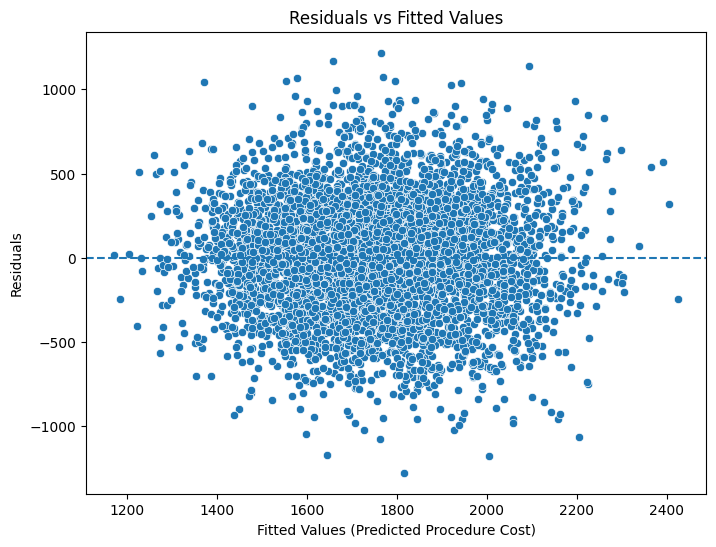

In [11]:
# Extract from fitted model
fitted_vals = model.fittedvalues
residuals = model.resid

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, linestyle='--')  # reference line
plt.xlabel("Fitted Values (Predicted Procedure Cost)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

The residual plot does not exhibit a clear funnel shape but remain relatively constant across fitted values. This indicates that the homoscedasticity assumption is reasonably satisfied, and this model is consistently inaccurate. There is no evidence showing a systematic breakdown at high pricing tiers; instead, errors remain constantly high at all levels, which means the reliability of this model is limited across all levels.